In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder

In [28]:
df=pd.read_excel("heart_disease.xlsx", sheet_name=1)

In [29]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [30]:
df.shape

(908, 13)

### 2. performing Exploratory Data Anallysis

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [32]:
### the information shows that there are 6 categorical columns and 6 numerical columns alomg with 1 logical column ie boolean

In [33]:
### Getting the statistical summary of the dataset
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [34]:
### Checking for missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [35]:
### there are 62 missing values in the Oldpeak column, hence we can replace those missing values with mean
df.fillna(df['oldpeak'].mean(), inplace=True)

In [36]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [37]:
### Checking for duplicates
df.duplicated().sum()

np.int64(1)

In [38]:
### there is 1 duplicate value present ,hence we can drop duplicates
df.drop_duplicates(inplace=True)

In [39]:
df.duplicated().sum()

np.int64(0)

#### Now visualizing the distribution of features, including histograms, box plots, and correlation matrices.

In [42]:
#### Finding numerical columns in the given dataset
num_col = df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

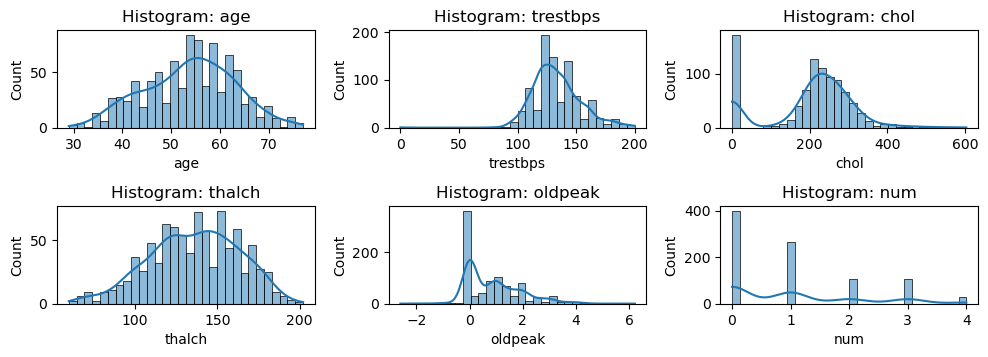

In [44]:
### Now plotting the histogram plot to see the feature distribution among the numerical variables
plt.figure(figsize=(10,5))
for i, col in enumerate(num_col, 1):
    plt.subplot(3,3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Histogram: {col}")
plt.tight_layout()
plt.show()

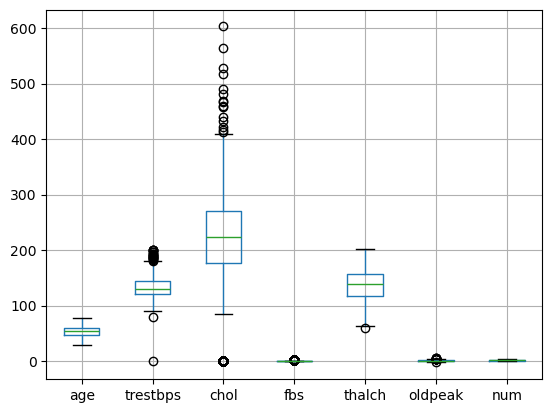

In [47]:
### Now plotting boxplot for detection of outliers
df.boxplot()
plt.show()

In [48]:
### now removing the outliers present in the dataset by capping technique
def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+1.5*IQR

    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(['int','float']).columns:

    outlier_capping(df,col)

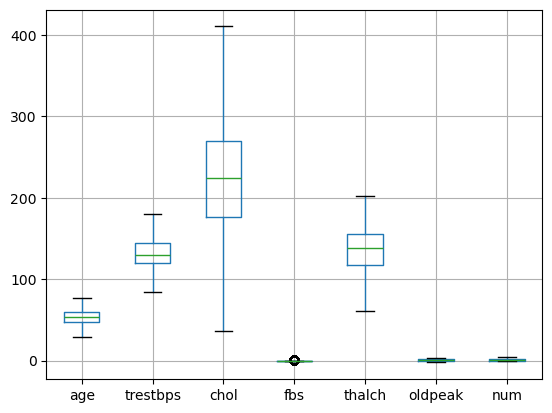

In [49]:
df.boxplot()
plt.show()

#### 3. Feature Engineering:
##### perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [52]:
## now looking out for the datatypes
df.dtypes

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

#### from the above information provided, the 'bs' column has boolean datatype , Hence we need to convert this to integer type

In [54]:
df['fbs'] = df['fbs'].astype(int)
df.dtypes

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs           int64
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [58]:
### Now finding out the categoricla columns in the dataset
cat_col=df.select_dtypes(include=['object']).columns
cat_col

Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

##### Now appling Labelling technique to convert categorical columns to numerical ones
##### Using label Encoder

In [59]:
label_enc=LabelEncoder()

In [60]:
for col in cat_col:
     df[col] = label_enc.fit_transform(df[col].astype(str)) 
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145.0,233.0,1,0,150.0,1,2.3,0,0,0
1,41,1,1,135.0,203.0,0,1,132.0,1,0.0,1,0,0
2,57,1,0,140.0,192.0,0,1,148.0,1,0.4,1,0,0
3,52,1,3,118.0,186.0,0,0,190.0,1,0.0,1,0,0
4,57,1,0,110.0,201.0,0,1,126.0,3,1.5,1,0,0


<Axes: >

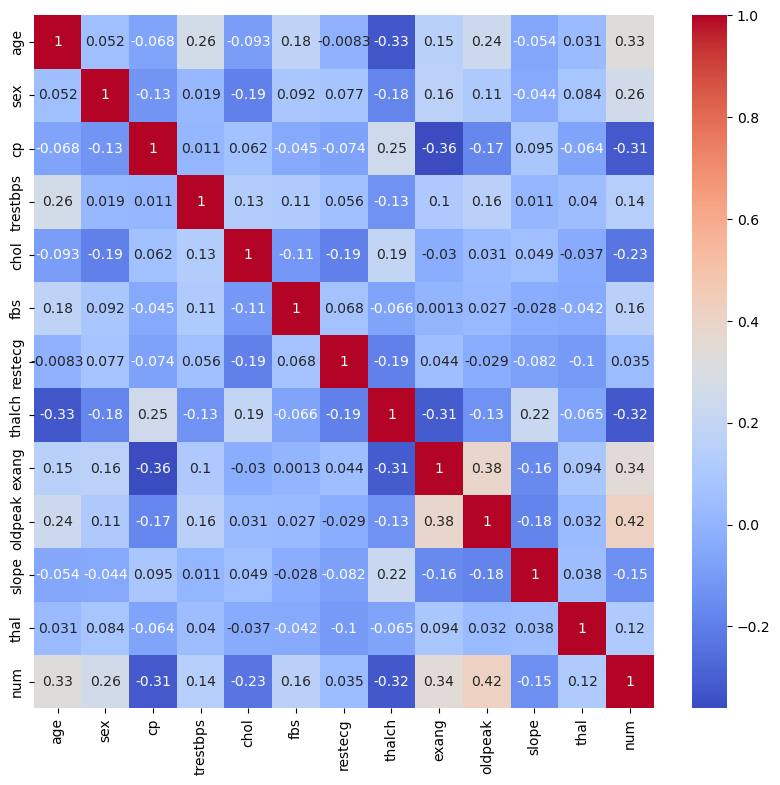

In [71]:
### Now finding out the correlation matrix to see the correlation between the variables
plt.figure(figsize=(10,9))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

#### 4.Decision Tree Classification:
##### Splitting the dataset into training and testing sets .

In [76]:
features=df.drop('num',axis=1)
target=df['num']

<Axes: xlabel='num', ylabel='count'>

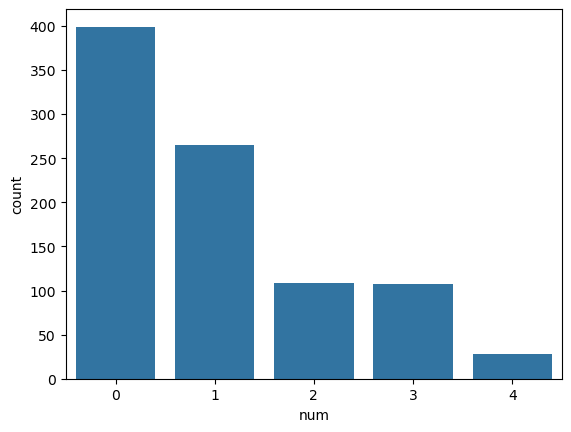

In [79]:
# ploting Countplot For Check target Feature is Balance Or Imbalance 
sns.countplot(x=target)

In [80]:
### Now applying scaling technique so as to bring data in a particular range
std_sca=StandardScaler()

In [81]:
Scaled_data=std_sca.fit_transform(features)

In [82]:
### Hold out to separate train and test data
x_train,x_test,y_train,y_test= train_test_split(features,target,train_size=0.8,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(x_test.shape)

(725, 12)
(182, 12)
(725,)
(182, 12)


In [83]:
### Now using decision tree classifier
dec_tree=DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=3)
dec_tree.fit(x_train,y_train)
y_pred=dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.4945054945054945

In [86]:
### Checking model performance on training data
dec_tree.score(x_train,y_train)

0.5889655172413794

In [87]:
## Checking model performance on testing data
dec_tree.score(x_test,y_test)

0.4945054945054945

In [88]:
from sklearn.metrics import classification_report , confusion_matrix, f1_score, recall_score, precision_score, roc_curve,roc_auc_score 
#Calculating Recall Score
recall = recall_score(y_test, y_pred, average='weighted') 
print("Weighted Recall:", np.round(recall, 2))

 # Calculating precision
precision = precision_score(y_test, y_pred, average='weighted')
print("Weighted Precision:", np.round(precision, 2))

 # Calculate Weighted F1-score
f1 = f1_score(y_test, y_pred, average='weighted')
print("Weighted F1-score:", np.round(f1, 2))

 #For Cunfusion matrix
cm = confusion_matrix(y_test,y_pred)
cm

Weighted Recall: 0.49
Weighted Precision: 0.41
Weighted F1-score: 0.45


array([[67, 10,  3,  0,  0],
       [20, 21, 12,  0,  0],
       [ 7, 13,  2,  0,  0],
       [ 6,  9,  6,  0,  0],
       [ 2,  1,  3,  0,  0]])

In [89]:
### Getting Classification report
print("Classification Report:\n", classification_report(y_test, y_pred)) 

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.84      0.74        80
           1       0.39      0.40      0.39        53
           2       0.08      0.09      0.08        22
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00         6

    accuracy                           0.49       182
   macro avg       0.22      0.26      0.24       182
weighted avg       0.41      0.49      0.45       182



<Axes: >

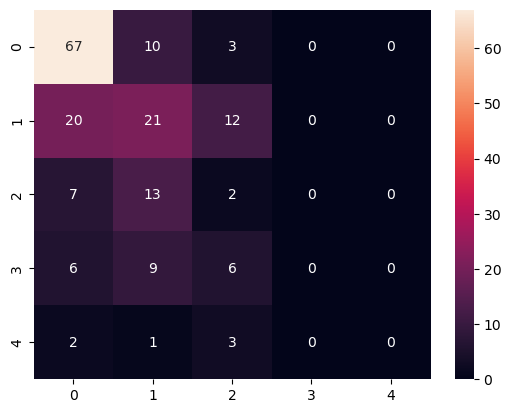

In [90]:
 ### plotting heatmap for confusion matrix
sns.heatmap(cm,annot=True)

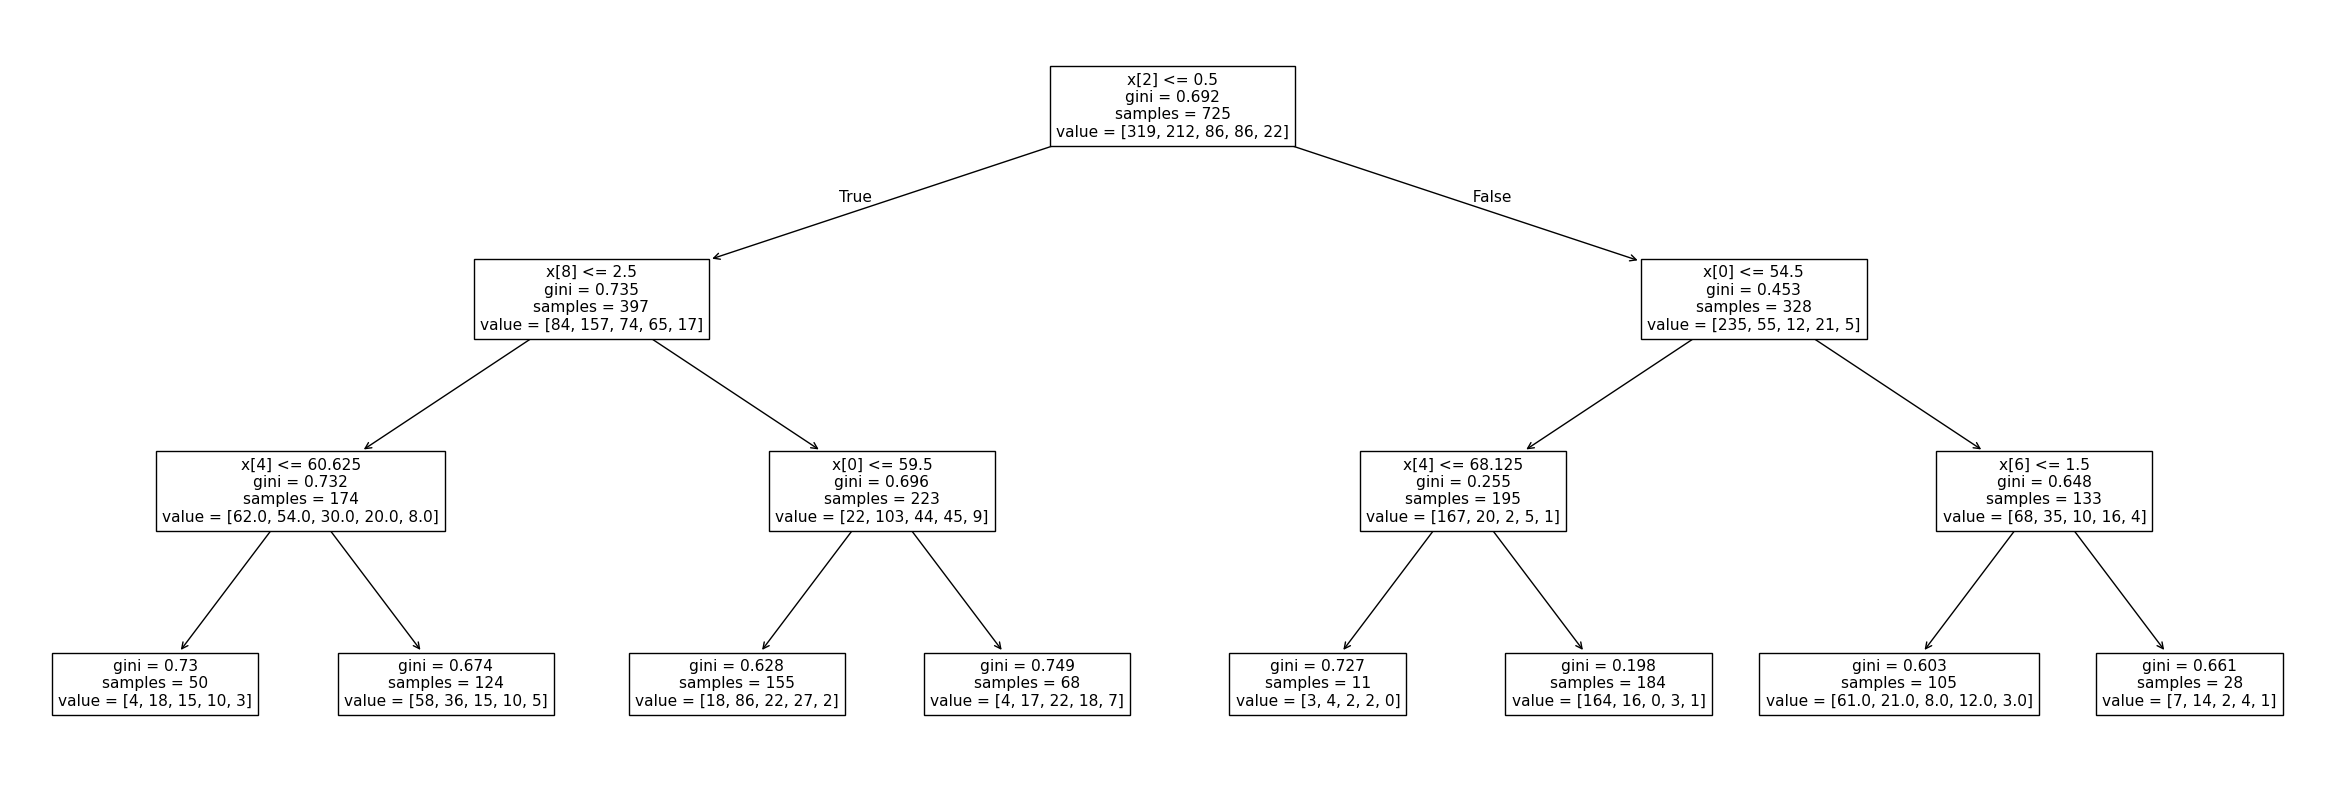

In [92]:
### plotting Decision tree
plt.figure(figsize=(30,10))
plot_tree(dec_tree)
plt.show()

In [95]:
# Checking Importance of Features according to this model 
importances = pd.Series(dec_tree.feature_importances_, index=features.columns)
importances = importances.sort_values(ascending=False)
print("Feature Importance:\n", importances) 

Feature Importance:
 cp          0.570432
age         0.181490
chol        0.117605
exang       0.089080
restecg     0.041393
sex         0.000000
trestbps    0.000000
fbs         0.000000
thalch      0.000000
oldpeak     0.000000
slope       0.000000
thal        0.000000
dtype: float64


#### 5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [97]:
df1 = df.copy() 
#Making New Feature from num feature it will convert 5 categories to only 2 categories (b'cuz Prediction goal is usually disease vs no disease') 
df1['num_binary'] = (df1['num'] > 0).astype(int) 
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num,num_binary
0,63,1,3,145.0,233.0,1,0,150.0,1,2.3,0,0,0,0
1,41,1,1,135.0,203.0,0,1,132.0,1,0.0,1,0,0,0
2,57,1,0,140.0,192.0,0,1,148.0,1,0.4,1,0,0,0
3,52,1,3,118.0,186.0,0,0,190.0,1,0.0,1,0,0,0
4,57,1,0,110.0,201.0,0,1,126.0,3,1.5,1,0,0,0


In [101]:
#Again Split data into features and target
fea1 = df1.iloc[:,:-2] 
targ1 = df1["num_binary"]
fea1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63,1,3,145.0,233.0,1,0,150.0,1,2.3,0,0
1,41,1,1,135.0,203.0,0,1,132.0,1,0.0,1,0
2,57,1,0,140.0,192.0,0,1,148.0,1,0.4,1,0
3,52,1,3,118.0,186.0,0,0,190.0,1,0.0,1,0
4,57,1,0,110.0,201.0,0,1,126.0,3,1.5,1,0


<Axes: xlabel='num_binary', ylabel='count'>

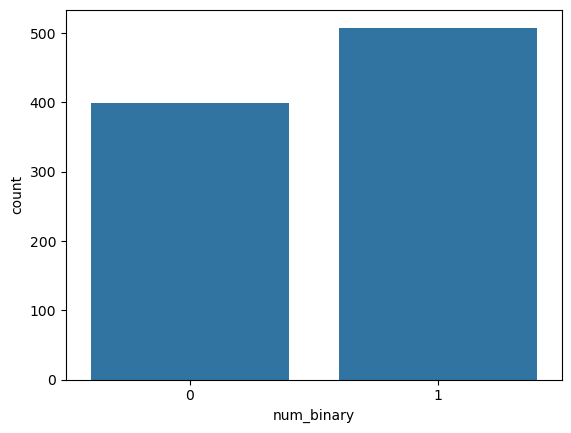

In [102]:
#Countplot For Check Data is Balance or not
sns.countplot(x =targ1) 

In [104]:
#Train test Split 
x1_train, x1_test, y1_train, y1_test = train_test_split(fea1, targ1, test_size=0.2, random_state=42, stratify=target) 

In [105]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV 

param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
} 
#Parameters Grid 
grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),param_grid,cv=5) #Find best hyperparameters
grid.fit(x1_train, y1_train) #Train model

best_tree = grid.best_estimator_ 

In [109]:
#Now training best model according gridsearchCV 
best_tree.fit(x1_train, y1_train) 

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       min_samples_leaf=5, min_samples_split=20,
                       random_state=42)

In [110]:
#model makes predictions 
cv_pred = best_tree.predict(x1_test) 

#### 6.Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

In [112]:
### Finding out model performance on training data
best_tree.score(x1_train, y1_train) 

0.8772413793103448

In [113]:
### Finding model performance on testing data
best_tree.score(x1_test,y1_test)

0.7197802197802198

In [115]:
### Claculating all performance metrices on new data

## Calculating recall
recall = recall_score(y1_test, cv_pred, average='weighted')
print("Weighted Recall:", np.round(recall, 2))

## Calculating precision
precision = precision_score(y1_test, cv_pred, average='weighted') 
print("Weighted Precision:", np.round(precision, 2))

## Calculating f1-score
f1 = f1_score(y1_test, cv_pred, average='weighted') 
print("Weighted F1-score:", np.round(f1, 2))

## Calculating AUC Score
auc_score = roc_auc_score(y1_test, cv_pred, average='weighted') 
print(f"Weighted AUC Score : {auc_score}")

## Finding out the confusion matrix
cm = confusion_matrix(y1_test,cv_pred) 
cm

Weighted Recall: 0.72
Weighted Precision: 0.72
Weighted F1-score: 0.72
Weighted AUC Score : 0.7189950980392157


array([[57, 23],
       [28, 74]])

<Axes: >

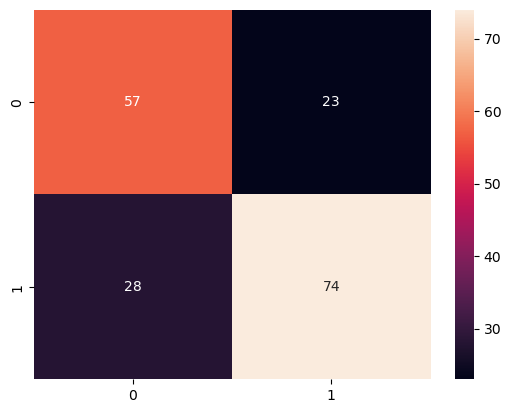

In [116]:
## plotting heat map for confusion matrix
sns.heatmap(cm,annot=True)

In [117]:
### Printing classification report of the model
print("Classification Report:\n", classification_report(y1_test, cv_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69        80
           1       0.76      0.73      0.74       102

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.72      0.72      0.72       182



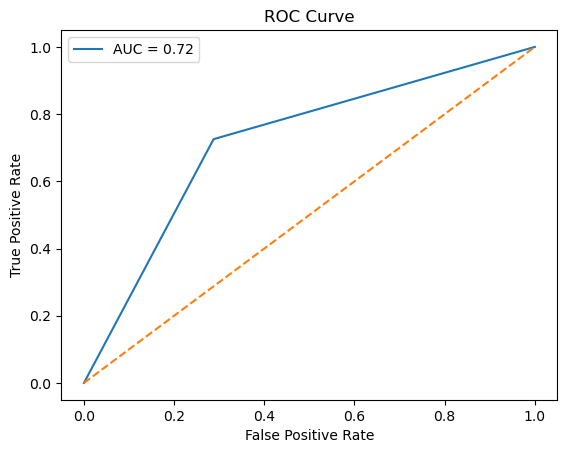

In [120]:
### Plotting ROC Curve
auc_score = roc_auc_score(y1_test, cv_pred)
fpr, tpr, _ = roc_curve(y1_test, cv_pred)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}') 
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

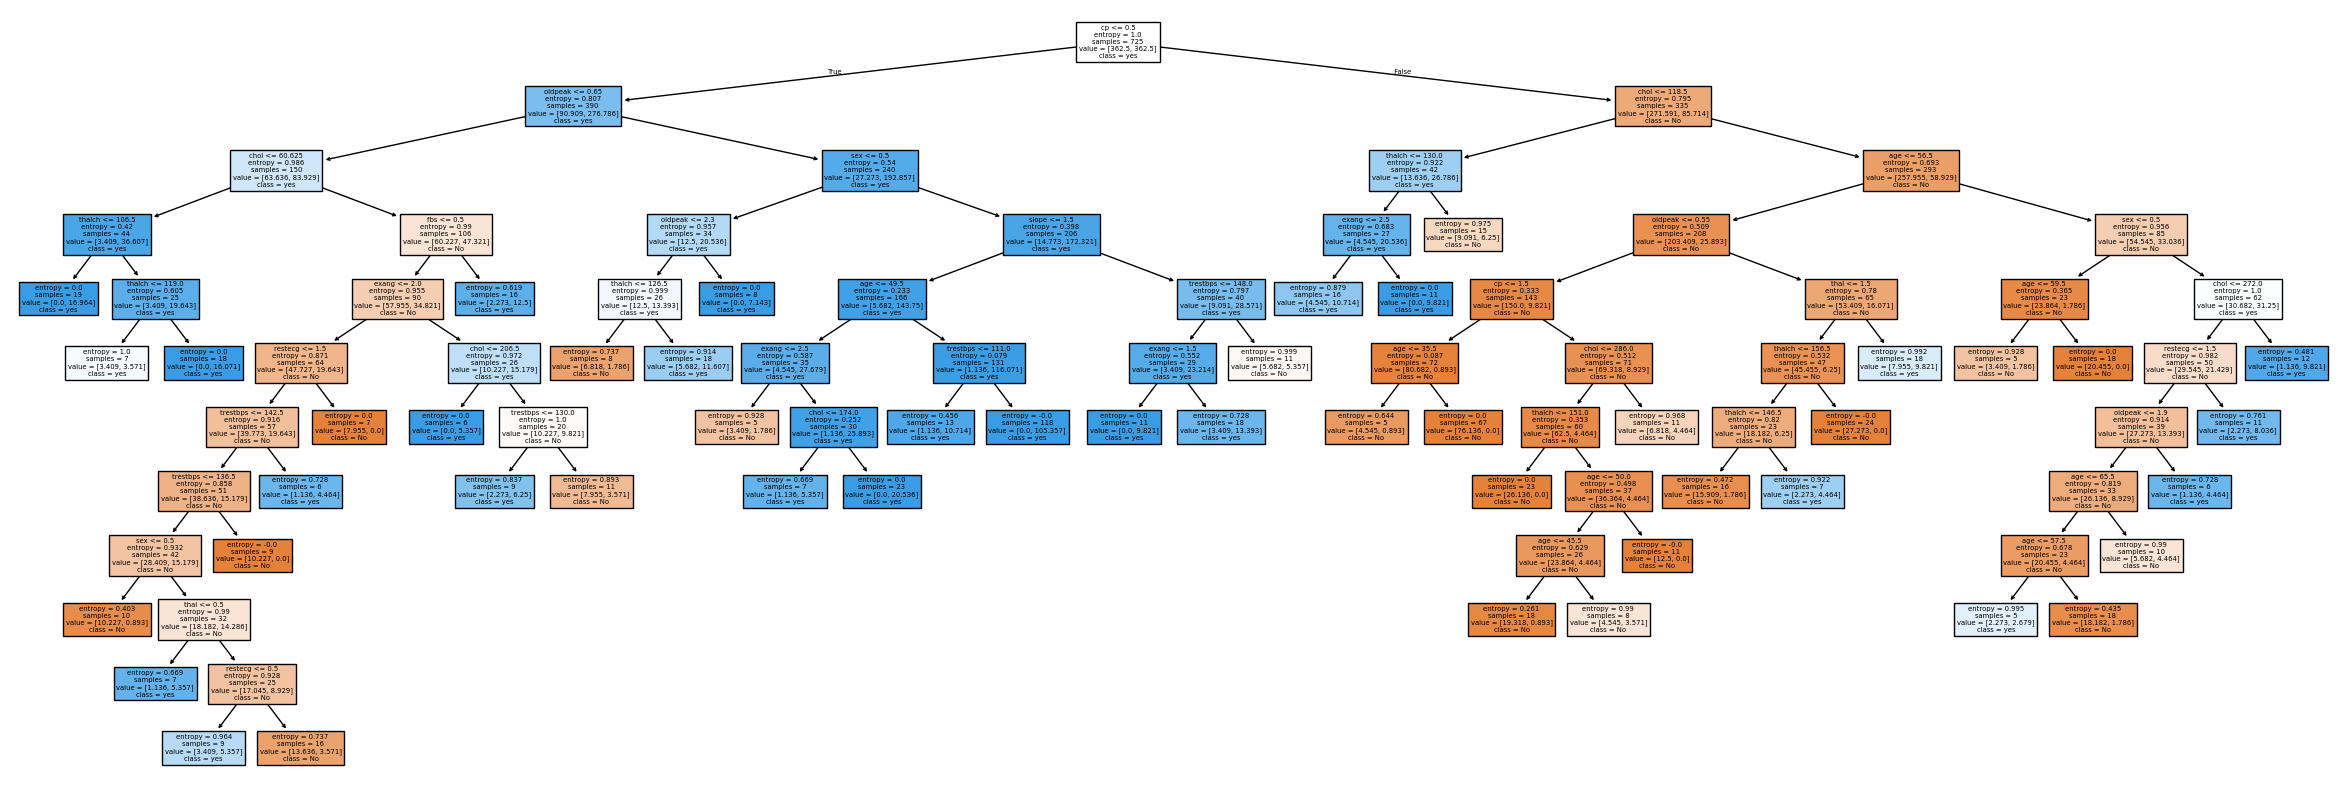

In [122]:
### Visualizzing the decision tree structur
fnames = fea1.columns
plt.figure(figsize=(30,10)) 
plot_tree(best_tree, class_names=['No','yes'], feature_names=fnames, filled=True) #Plot Decision Tree
plt.show()

#### Interview Questions:
#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
##### max_depth
Limits the depth of the tree.
Smaller depth reduces overfitting; larger depth may overfit.
###### min_samples_split
Minimum samples required to split a node.
Higher value makes the tree more general.
###### min_samples_leaf
Minimum samples required at a leaf node.
Helps smooth predictions and reduces overfitting.
##### criterion (gini, entropy)
Measure used to split nodes.
Affects how splits are chosen.
###### class_weight
Weights classes during training.
Useful for handling imbalanced datasets.

#### 2.What is the difference between the Label encoding and One-hot encoding?
##### Label Encoding :
Label Encoding converts categorical variables into numerical labels by assigning a unique integer to each category, within a single column. It's efficient for memory and ideal for ordinal data with inherent order (e.g., low/medium/high ratings). 
Tree-based models like Decision Trees and Random Forests handle it naturally without assuming false hierarchies. However, for nominal data like colors, it risks implying unintended ordinal relationships, potentially misleading distance-based algorithms like KNN or SVM.
##### One-Hot Encoding:
One-Hot Encoding transforms each category into a binary vector with a separate column per unique value. This avoids any ordinal assumptions, making it perfect for nominal data like city names or colors. It's preferred for linear models, logistic regression, and neural networks that treat features independently. Drawbacks include the curse of dimensionality with many categories, leading to sparse matrices and higher computational costs—use sparse representations or dimensionality reduction if needed.